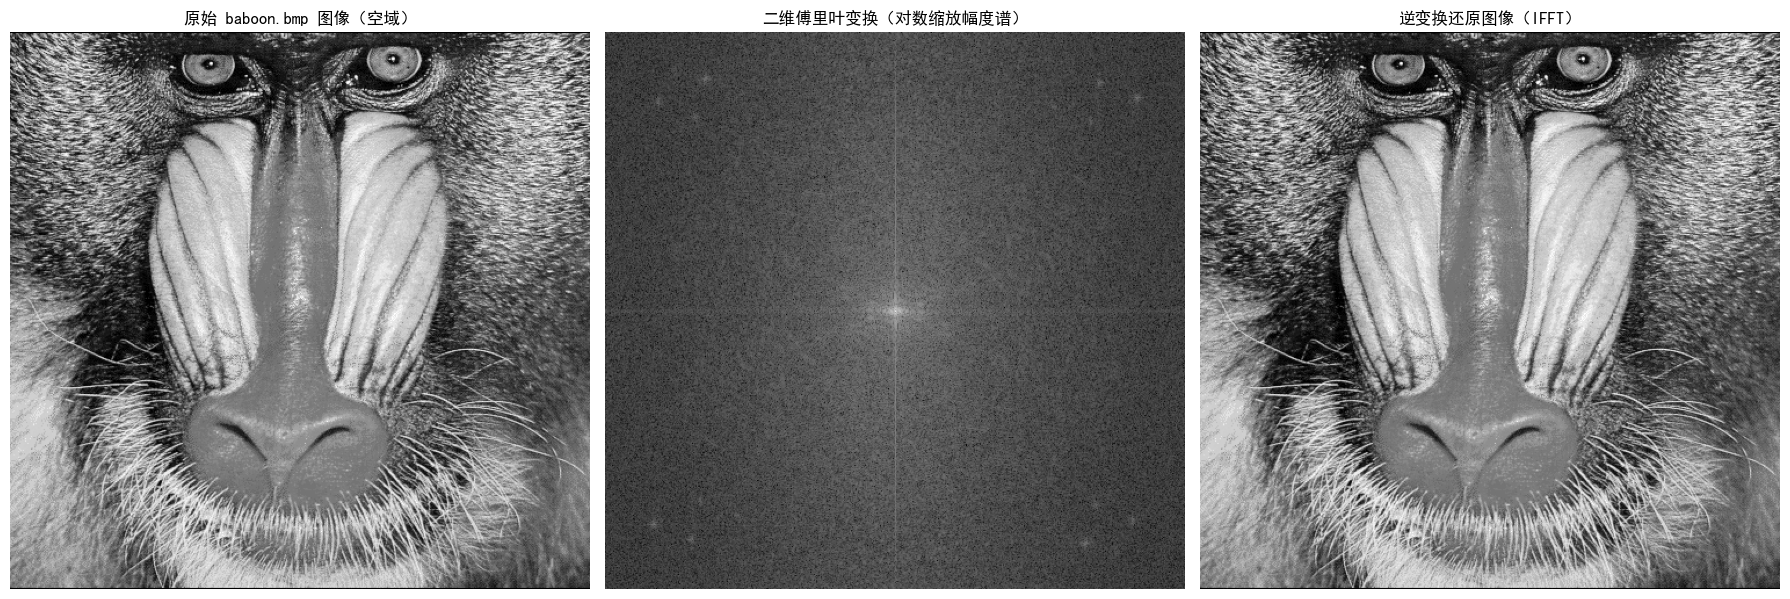

逆变换与baboon.bmp原图的均方误差：0.0000000000


In [3]:
# 导入库
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 设置字体（避免中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# ===================== 二维傅里叶变换（baboon.bmp） =====================
# 1. 读取 baboon.bmp 图片（核心：路径适配）
# 说明：确保 baboon.bmp 与Jupyter Notebook文件在同一目录下
img_path = "baboon.bmp"

# 读取BMP格式图片，强制转为灰度图
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# 检查图片读取是否成功（BMP格式常见问题排查）
if img is None:
    raise ValueError("""
    图片读取失败！请检查：
    1. baboon.bmp 是否在当前Notebook同一文件夹下；
    2. 文件名是否拼写正确（区分大小写，如Baboon.bmp≠baboon.bmp）；
    3. 图片是否损坏（可尝试重新下载baboon.bmp测试图）。
    """)

# 归一化到0-1范围（消除像素值255的量级影响）
img = img / 255.0

# 2. 执行二维FFT + 频谱中心化（核心步骤）
fft2_result = np.fft.fft2(img)          # 二维快速傅里叶变换
fft2_shift = np.fft.fftshift(fft2_result)  # 低频分量移到频谱中心

# 3. 频域幅度谱处理（对数缩放，可视化关键）
amplitude = np.abs(fft2_shift)         # 原始幅度谱（动态范围极大）
amplitude_log = np.log(1 + amplitude)  # 对数缩放，让高频细节可见

# 4. 逆FFT还原图像（验证可逆性）
ifft2_shift = np.fft.ifftshift(fft2_shift)  # 逆中心化
ifft2_result = np.fft.ifft2(ifft2_shift)    # 逆二维傅里叶变换
img_recon = np.real(ifft2_result)           # 取实部（虚部为浮点误差）

# 5. 可视化结果（原图+频域+还原图）
plt.figure(figsize=(18, 6))

# 子图1：原始狒狒灰度图
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('原始 baboon.bmp 图像（空域）', fontsize=12)
plt.axis('off')

# 子图2：频域幅度谱（对数缩放）
plt.subplot(1, 3, 2)
plt.imshow(amplitude_log, cmap='gray')
plt.title('二维傅里叶变换（对数缩放幅度谱）', fontsize=12)
plt.axis('off')

# 子图3：逆变换还原图
plt.subplot(1, 3, 3)
plt.imshow(img_recon, cmap='gray')
plt.title('逆变换还原图像（IFFT）', fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

# 输出还原误差（数值越小越精准）
error = np.mean((img_recon - img)**2)
print(f"逆变换与baboon.bmp原图的均方误差：{error:.10f}")